# Amortized collective inference with NPE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
import numpy as np
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import WF

import matplotlib as mpl
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.simplefilter('ignore', Warning)


generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


# Get Collective Posterior
## $P(\theta|X_{1},...X_{n}) = $${{P(\theta)}^{1-n}\Pi_{i}[P(\theta|X_{i})]} \over {\int{{P(\zeta)}^{1-n}}\Pi_{i}[P(\zeta|X_{i})]d\zeta}$

In [16]:
# Prior doesn't have to be identical to network's prior (here it is)
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open(f'posteriors/posterior_WF_30000_20.pkl', 'rb'))

collective_posteriors = {}

lines = ['wt','ltr','ars','all']
for line in lines:
    amortized_posterior = posterior_chuong
    Xs = pd.read_csv(f'empirical_data/{line}.csv', index_col=0) # observations
    Xs = torch.tensor(np.array(Xs), dtype=torch.float32)
    log_C = 1
    op = CollectivePosterior(prior, Xs, amortized_posterior,log_C, epsilon=-100)
    op.epsilon = op.estimate_epsilon(Xs)
    # op.get_log_C()
    collective_posteriors[line] = op # to use throughout the notebook
    # op.samples = op.sample(100, keep=True)
    op.samples = op.sample_via_sir_jitter()

rep_colors = {'wt':"black", 'ltr':"#6699cc", 'ars': "#e26d5c", 'all':"#DEBD52"}
label_dict = {'wt': 'A', 'ltr': 'B', 'ars': 'C', 'all': 'D'}

Evaluating 100000 samples: 100%|██████████| 8/8 [00:00<00:00, 20.77it/s]


# Collective Posterior Validation

## Predictive Checks - Simulate Collective Posterior MAP and compare to empirical observations

Drawing 50 posterior samples:   0%|          | 0/50 [00:00<?, ?it/s]

Drawing 50 posterior samples:   0%|          | 0/50 [00:00<?, ?it/s]

Drawing 50 posterior samples:   0%|          | 0/50 [00:00<?, ?it/s]

Drawing 50 posterior samples:   0%|          | 0/50 [00:00<?, ?it/s]

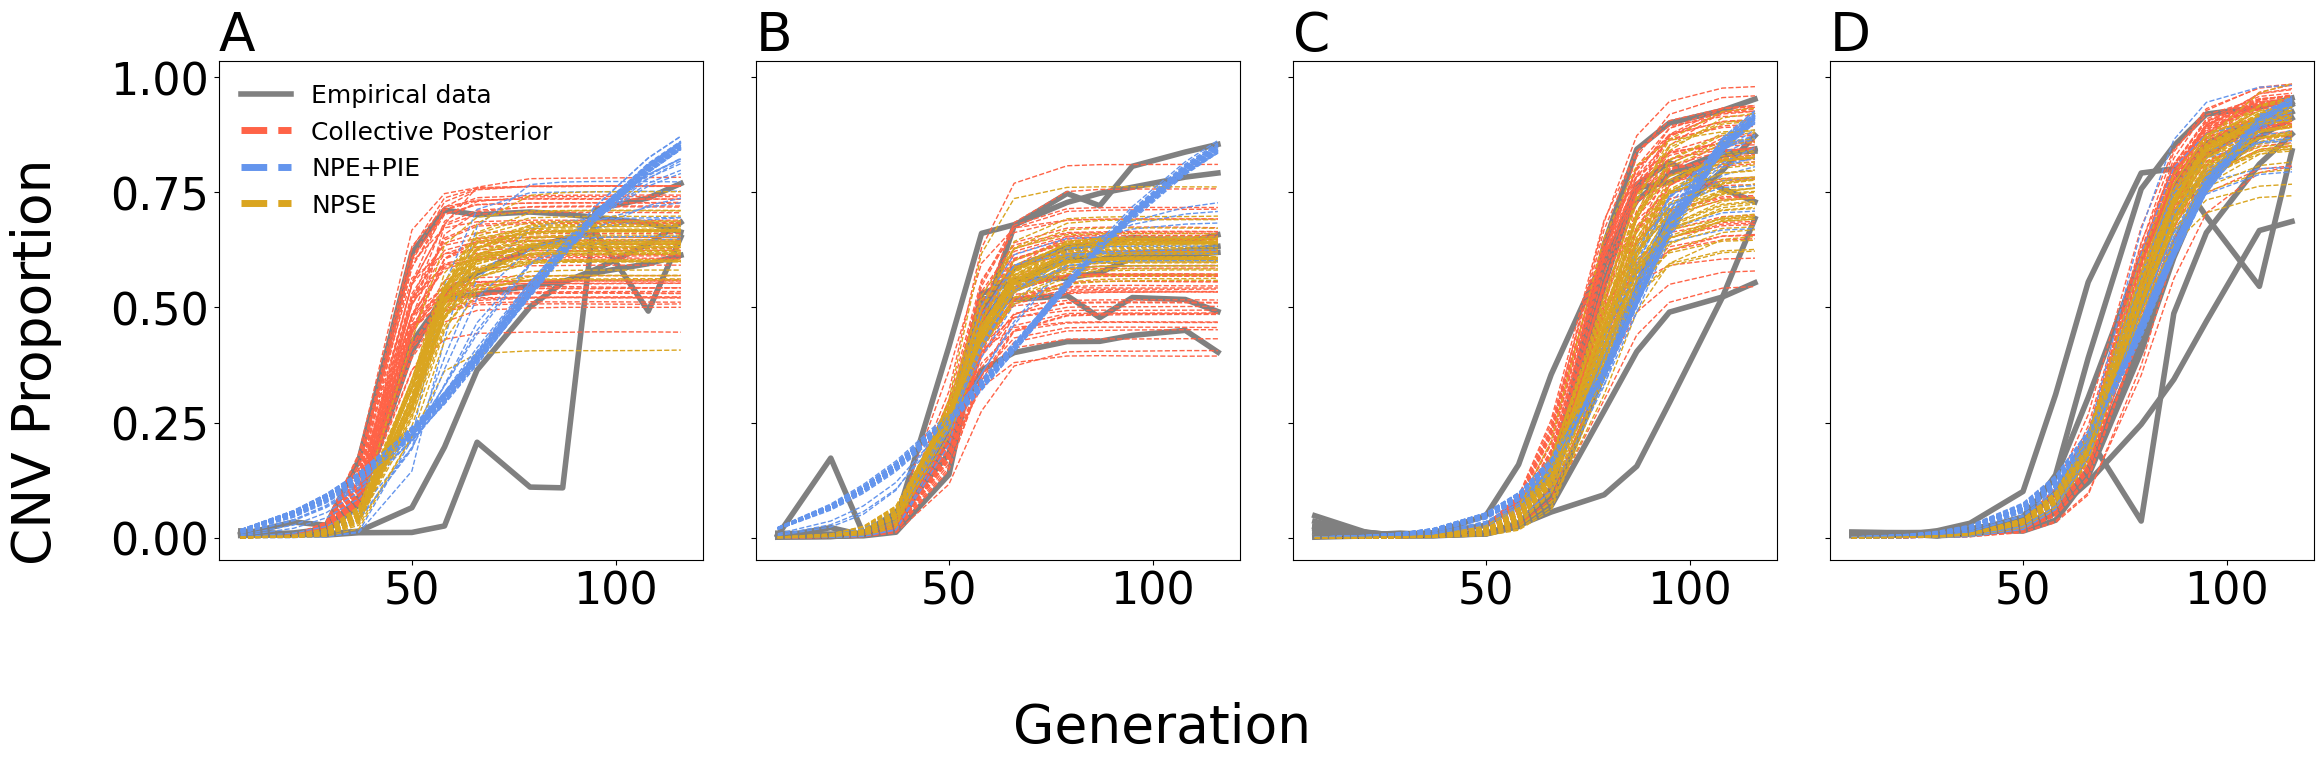

In [17]:
posterior_iid = pickle.load(open('posteriors/posterior_iid_WF_30000_20.pkl', 'rb'))
change_font(32)

n = 50
lw = n/50

def plot_collective_ppc(ax, line, color):
    cp = collective_posteriors[line]
    samples = cp.samples[:n]
    Xs = collective_posteriors[line].Xs
    for i in range(len(Xs)):
        ax.plot(generation.astype('int'),Xs[i], color='grey', lw=4, label='Empirical data' if i==0 and line=='wt' else '')
    for j in range(len(samples)):
        ax.plot(generation.astype('int'), WF(parameters=samples[j]), ls='--', color=color, lw=lw, label='Collective Posterior' if j==0 and line=='wt' else '')
    
fig, ax = plt.subplots(1,4, figsize=(24,8), sharex=True, sharey=True, tight_layout=True)
fig.supylabel('CNV Proportion')
fig.supxlabel('Generation')

for k in range(len(lines)):
    # i = (k%2, k//2)
    line = lines[k]
    plot_collective_ppc(ax[k], line, 'tomato')
    ax[k].set_title(label_dict[line], loc = 'left')

for k in range(len(lines)):
    # i = k%2, k//2
    line = lines[k]
    full_X = torch.empty(10,12)
    X = collective_posteriors[line].Xs
    full_X[:len(X)] = X
    full_X[len(X):] = torch.nan
    samples = posterior_iid.set_default_x(full_X).sample((n,))
    samples_npse = torch.load(f'samples_npse_{line}_noisy.pt')[:n]
    for j in range(len(samples)):
        ax[k].plot(generation.astype('int'), WF(parameters=samples[j]), color='cornflowerblue', ls='--', lw=lw, label='NPE+PIE' if j==0 and k==0 else '')
        ax[k].plot(generation.astype('int'), WF(parameters=samples_npse[j]), color='goldenrod', ls='--', lw=lw, label='NPSE' if j==0 and k==0 else '')
leg = ax[0].legend(fontsize=18, markerscale=80, frameon=False)
leg.get_lines()[1].set_linewidth(5)
leg.get_lines()[2].set_linewidth(5)
leg.get_lines()[3].set_linewidth(5)

wt tensor([-0.6232, -5.2209, -4.7928]) tensor([-0.6783, -5.0465, -4.6305])
ltr tensor([-0.6210, -5.6769, -5.1393]) tensor([-0.7449, -4.7151, -4.1919])
ars tensor([-0.7996, -5.7850, -5.6104]) tensor([-0.8036, -5.7968, -5.5406])
all tensor([-0.8381, -5.3057, -5.4550]) tensor([-0.8724, -5.0963, -5.1826])


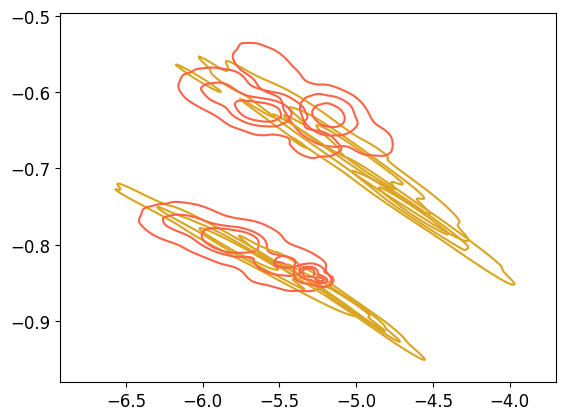

In [15]:
from seaborn import kdeplot
change_font(12)
# fig, ax = plt.subplots(1,3)
for line in lines:
    samples_npse = torch.load(f'samples_npse_{line}_noisy.pt')
    kdeplot(x=samples_npse[:,1], y=samples_npse[:,0], color='goldenrod', lw=0.5, levels=4)
    kdeplot(x=collective_posteriors[line].samples[:,1], y=collective_posteriors[line].samples[:,0], color='tomato', lw=0.5, levels=4)
    print(line, collective_posteriors[line].samples.mean(0), samples_npse.mean(0))